# 04 - Classical ML Model Training

**Cycle Rack Audio Classification Project**

This notebook trains classical machine learning models on the extracted audio features.

## Models to Train:
1. **Support Vector Machine (SVM)**: Effective for high-dimensional feature spaces
2. **Random Forest**: Ensemble method using decision trees
3. **XGBoost**: Gradient boosting for structured data
4. **k-Nearest Neighbors (k-NN)**: Distance-based classifier

## Training Pipeline:
- Load preprocessed features
- Train/validation/test split
- Hyperparameter tuning with GridSearchCV
- Model training and evaluation
- Performance comparison

In [1]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")
print(f"XGBoost version: {__import__('xgboost').__version__}")

Libraries imported successfully!
Scikit-learn version: 1.7.2
XGBoost version: 3.1.1


In [3]:
## Configuration and Path Setup

In [4]:
# Get paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
FEATURES_DIR = DATA_DIR / "features"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Path Configuration:")
print(f"  Features directory: {FEATURES_DIR}")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Results directory: {RESULTS_DIR}")
print(f"\nPath checks:")
print(f"  Features directory exists: {FEATURES_DIR.exists()}")
print(f"  Models directory exists: {MODELS_DIR.exists()}")
print(f"  Results directory exists: {RESULTS_DIR.exists()}")

# Configuration
CONFIG = {
    'TEST_SIZE': 0.2,
    'VAL_SIZE': 0.1,  # 10% of remaining after test split
    'RANDOM_STATE': 42,
    'CV_FOLDS': 5,  # Cross-validation folds
    'N_JOBS': -1,  # Use all CPU cores
    'VERBOSE': 1
}

print(f"\nTraining Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Path Configuration:
  Features directory: /workspaces/BikeAIv2/data/features
  Models directory: /workspaces/BikeAIv2/models
  Results directory: /workspaces/BikeAIv2/results

Path checks:
  Features directory exists: True
  Models directory exists: True
  Results directory exists: True

Training Configuration:
  TEST_SIZE: 0.2
  VAL_SIZE: 0.1
  RANDOM_STATE: 42
  CV_FOLDS: 5
  N_JOBS: -1
  VERBOSE: 1


In [5]:
## Load Preprocessed Features

In [6]:
# Load scaled features
features_path = FEATURES_DIR / "classical_features_scaled.csv"
print(f"Loading features from: {features_path}")

features_df = pd.read_csv(features_path)

print(f"\nDataset loaded:")
print(f"  Total samples: {len(features_df)}")
print(f"  Total features: {len(features_df.columns) - 3}")  # Exclude metadata
print(f"  Columns: {features_df.columns.tolist()[:10]}...")

# Separate features and labels
metadata_columns = ['filename', 'duration', 'class']
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

X = features_df[feature_columns].values
y = features_df['class'].values

# Encode class labels to numeric
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y_encoded.shape}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {cls}: {count} samples ({count/len(y)*100:.1f}%)")

# Save label encoder
joblib.dump(label_encoder, MODELS_DIR / 'label_encoder.pkl')
print(f"\n✓ Label encoder saved")

Loading features from: /workspaces/BikeAIv2/data/features/classical_features_scaled.csv

Dataset loaded:
  Total samples: 1399
  Total features: 75
  Columns: ['filename', 'duration', 'class', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median', 'mfcc_3_mean']...

Feature matrix shape: (1399, 75)
Labels shape: (1399,)

Class distribution:
  angle_grinder: 30 samples (2.1%)
  background: 1346 samples (96.2%)
  other_power_tools: 23 samples (1.6%)

✓ Label encoder saved


In [7]:
## Train/Validation/Test Split

In [8]:
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y_encoded
)

# Second split: separate validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=CONFIG['VAL_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y_temp
)

print(f"{'='*60}")
print("DATA SPLIT SUMMARY")
print(f"{'='*60}")
print(f"Training set: {X_train.shape}")
print(f"  Class distribution: {np.unique(y_train, return_counts=True)}")
print(f"\nValidation set: {X_val.shape}")
print(f"  Class distribution: {np.unique(y_val, return_counts=True)}")
print(f"\nTest set: {X_test.shape}")
print(f"  Class distribution: {np.unique(y_test, return_counts=True)}")

DATA SPLIT SUMMARY
Training set: (1007, 75)
  Class distribution: (array([0, 1, 2]), array([ 22, 969,  16]))

Validation set: (112, 75)
  Class distribution: (array([0, 1, 2]), array([  2, 108,   2]))

Test set: (280, 75)
  Class distribution: (array([0, 1, 2]), array([  6, 269,   5]))


In [9]:
## Model Training with Hyperparameter Tuning

In [10]:
# Define hyperparameter grids for each model
param_grids = {
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },

    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },

    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }
}

print("Hyperparameter grids defined for all models")
print(f"\nGrid sizes:")
for model_name, grid in param_grids.items():
    grid_size = np.prod([len(v) for v in grid.values()])
    print(f"  {model_name}: {grid_size} combinations")

Hyperparameter grids defined for all models

Grid sizes:
  SVM: 60 combinations
  RandomForest: 216 combinations
  XGBoost: 108 combinations
  KNN: 30 combinations


In [11]:
def train_and_evaluate_model(model, param_grid, X_train, y_train, X_val, y_val, model_name, config):
    """
    Train a model with GridSearchCV and evaluate on validation set.
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=config['CV_FOLDS'],
        scoring='accuracy',
        n_jobs=config['N_JOBS'],
        verbose=config['VERBOSE']
    )

    # Train
    print(f"Starting grid search with {config['CV_FOLDS']}-fold cross-validation...")
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_cv_score = grid_search.best_score_

    print(f"\n✓ Training complete!")
    print(f"Best CV Score: {best_cv_score:.4f}")
    print(f"Best Parameters: {best_params}")

    # Evaluate on validation set
    y_val_pred = best_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    print(f"\nValidation Metrics:")
    print(f"  Accuracy: {val_accuracy:.4f}")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall: {val_recall:.4f}")
    print(f"  F1-Score: {val_f1:.4f}")

    results = {
        'model_name': model_name,
        'best_model': best_model,
        'best_params': best_params,
        'best_cv_score': best_cv_score,
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_predictions': y_val_pred
    }

    return results

print("Training function defined")

Training function defined


In [12]:
# Train SVM
svm_model = SVC(random_state=CONFIG['RANDOM_STATE'])
svm_results = train_and_evaluate_model(
    svm_model, 
    param_grids['SVM'],
    X_train, y_train, X_val, y_val,
    'SVM',
    CONFIG
)

# Save model
joblib.dump(svm_results['best_model'], MODELS_DIR / 'svm_model.pkl')
print(f"\n✓ SVM model saved")


Training SVM
Starting grid search with 5-fold cross-validation...
Fitting 5 folds for each of 60 candidates, totalling 300 fits



✓ Training complete!
Best CV Score: 0.9911
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Validation Metrics:
  Accuracy: 0.9911
  Precision: 0.9940
  Recall: 0.9911
  F1-Score: 0.9905

✓ SVM model saved


In [13]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=CONFIG['RANDOM_STATE'])
rf_results = train_and_evaluate_model(
    rf_model,
    param_grids['RandomForest'],
    X_train, y_train, X_val, y_val,
    'Random Forest',
    CONFIG
)

# Save model
joblib.dump(rf_results['best_model'], MODELS_DIR / 'random_forest_model.pkl')
print(f"\n✓ Random Forest model saved")


Training Random Forest
Starting grid search with 5-fold cross-validation...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Training complete!
Best CV Score: 0.9901
Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Validation Metrics:
  Accuracy: 0.9911
  Precision: 0.9940
  Recall: 0.9911
  F1-Score: 0.9905

✓ Random Forest model saved


In [14]:
# Train XGBoost
xgb_model = XGBClassifier(
    random_state=CONFIG['RANDOM_STATE'],
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_results = train_and_evaluate_model(
    xgb_model,
    param_grids['XGBoost'],
    X_train, y_train, X_val, y_val,
    'XGBoost',
    CONFIG
)

# Save model
joblib.dump(xgb_results['best_model'], MODELS_DIR / 'xgboost_model.pkl')
print(f"\n✓ XGBoost model saved")


Training XGBoost
Starting grid search with 5-fold cross-validation...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✓ Training complete!
Best CV Score: 0.9901
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

Validation Metrics:
  Accuracy: 0.9911
  Precision: 0.9940
  Recall: 0.9911
  F1-Score: 0.9905

✓ XGBoost model saved


In [15]:
# Train k-NN
knn_model = KNeighborsClassifier()
knn_results = train_and_evaluate_model(
    knn_model,
    param_grids['KNN'],
    X_train, y_train, X_val, y_val,
    'k-NN',
    CONFIG
)

# Save model
joblib.dump(knn_results['best_model'], MODELS_DIR / 'knn_model.pkl')
print(f"\n✓ k-NN model saved")


Training k-NN
Starting grid search with 5-fold cross-validation...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Training complete!
Best CV Score: 0.9851
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Validation Metrics:
  Accuracy: 0.9911
  Precision: 0.9940
  Recall: 0.9911
  F1-Score: 0.9905

✓ k-NN model saved


In [16]:
## Model Comparison

In [17]:
# Collect all results
all_results = {
    'SVM': svm_results,
    'Random Forest': rf_results,
    'XGBoost': xgb_results,
    'k-NN': knn_results
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'CV Score': [r['best_cv_score'] for r in all_results.values()],
    'Val Accuracy': [r['val_accuracy'] for r in all_results.values()],
    'Val Precision': [r['val_precision'] for r in all_results.values()],
    'Val Recall': [r['val_recall'] for r in all_results.values()],
    'Val F1-Score': [r['val_f1'] for r in all_results.values()]
})

print(f"\n{'='*60}")
print("MODEL COMPARISON (Validation Set)")
print(f"{'='*60}")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"\n✓ Comparison saved to {RESULTS_DIR / 'model_comparison.csv'}")


MODEL COMPARISON (Validation Set)
        Model  CV Score  Val Accuracy  Val Precision  Val Recall  Val F1-Score
          SVM  0.991069      0.991071       0.994048    0.991071      0.990476
Random Forest  0.990079      0.991071       0.994048    0.991071      0.990476
      XGBoost  0.990065      0.991071       0.994048    0.991071      0.990476
         k-NN  0.985104      0.991071       0.994048    0.991071      0.990476

✓ Comparison saved to /workspaces/BikeAIv2/results/model_comparison.csv


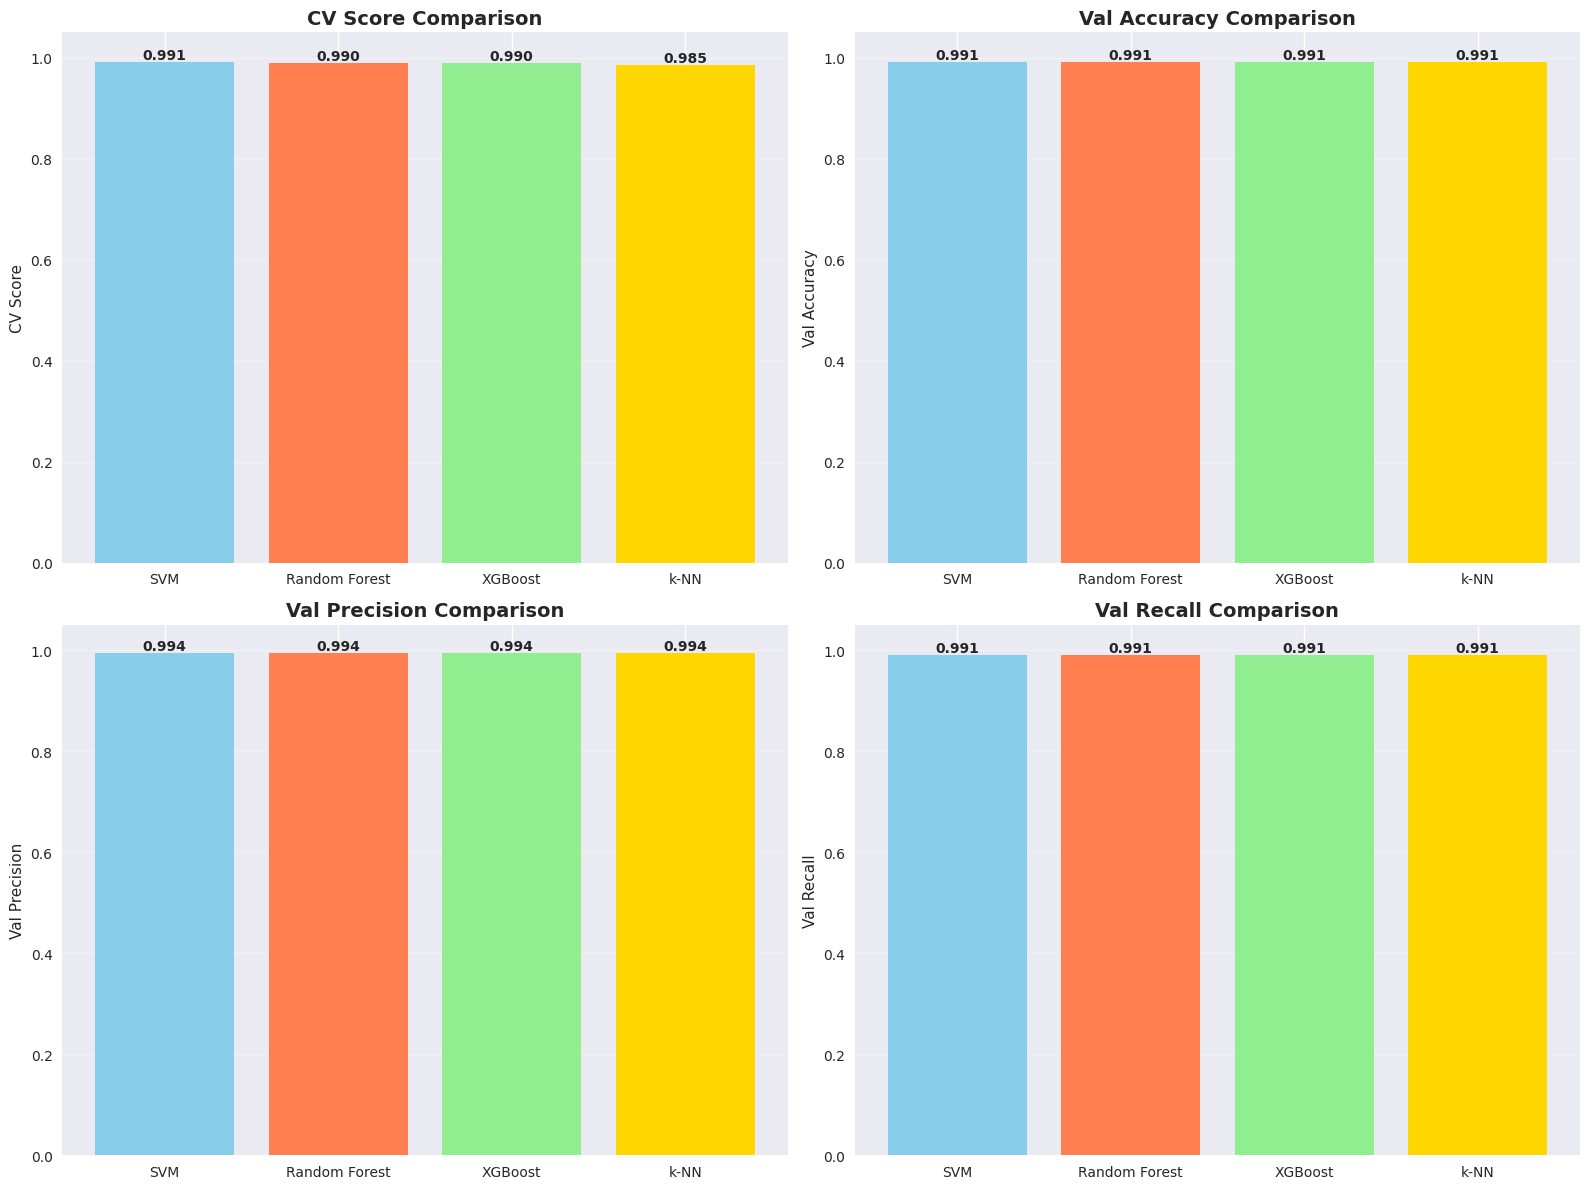

✓ Comparison visualization saved


In [18]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = ['CV Score', 'Val Accuracy', 'Val Precision', 'Val Recall']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=['skyblue', 'coral', 'lightgreen', 'gold'])
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Comparison visualization saved")

In [19]:
## Test Set Evaluation (Best Model)

In [20]:
# Find best model based on validation F1-score
best_model_name = comparison_df.loc[comparison_df['Val F1-Score'].idxmax(), 'Model']
best_model_results = all_results[best_model_name]
best_model = best_model_results['best_model']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Validation F1-Score: {best_model_results['val_f1']:.4f}")

# Evaluate on test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f"\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Classification report
print(f"\nClassification Report:")
class_names = label_encoder.classes_
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))


BEST MODEL: SVM
Validation F1-Score: 0.9905

Test Set Metrics:
  Accuracy: 0.9893
  Precision: 0.9911
  Recall: 0.9893
  F1-Score: 0.9875

Classification Report:
                   precision    recall  f1-score   support

    angle_grinder       0.75      1.00      0.86         6
       background       1.00      1.00      1.00       269
other_power_tools       1.00      0.40      0.57         5

         accuracy                           0.99       280
        macro avg       0.92      0.80      0.81       280
     weighted avg       0.99      0.99      0.99       280



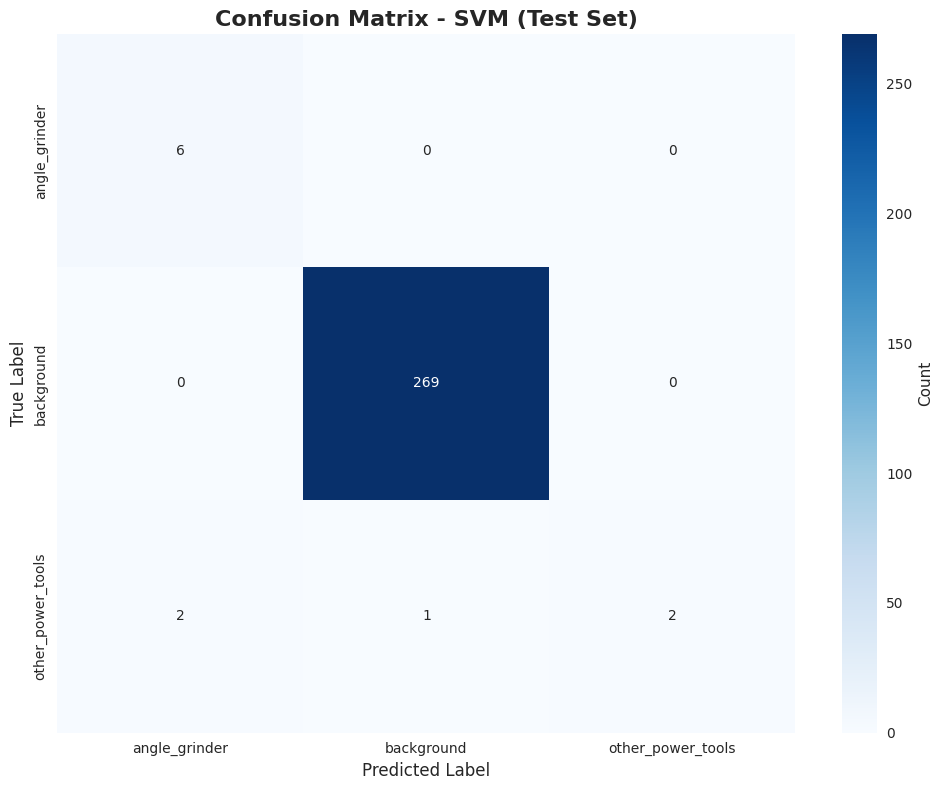

✓ Confusion matrix saved


In [21]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'confusion_matrix_{best_model_name.replace(" ", "_")}.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Confusion matrix saved")

In [22]:
# Save all test results
test_results = {
    'best_model_name': best_model_name,
    'best_params': best_model_results['best_params'],
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1)
}

with open(RESULTS_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

print(f"✓ Test results saved to {RESULTS_DIR / 'test_results.json'}")

print(f"\n{'='*60}")
print("CLASSICAL ML TRAINING COMPLETE")
print(f"{'='*60}")
print(f"\nBest Model: {best_model_name}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"\nAll models saved to: {MODELS_DIR}")
print(f"Results saved to: {RESULTS_DIR}")
print(f"\n✓ Ready for CNN training (notebook 05) and final comparison (notebook 06)!")

✓ Test results saved to /workspaces/BikeAIv2/results/test_results.json

CLASSICAL ML TRAINING COMPLETE

Best Model: SVM
Test F1-Score: 0.9875

All models saved to: /workspaces/BikeAIv2/models
Results saved to: /workspaces/BikeAIv2/results

✓ Ready for CNN training (notebook 05) and final comparison (notebook 06)!
